In [33]:
import matplotlib.pyplot as plt
import numpy as np

def draw_image(image):
    plt.imshow(image, cmap='gray')
    plt.show()

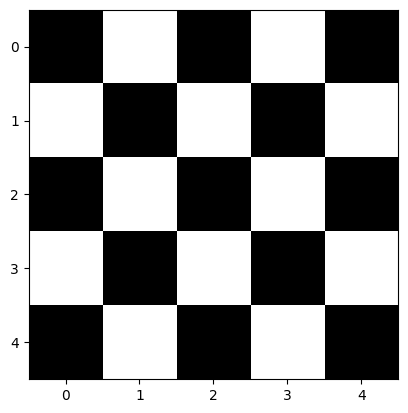

In [86]:
array = np.array([[0, 1, 0, 1, 0],
                 [1,0, 1, 0, 1],
                 [0, 1, 0, 1, 0],   
                 [1,0, 1, 0, 1],
                 [0, 1, 0, 1, 0]])
draw_image(array)

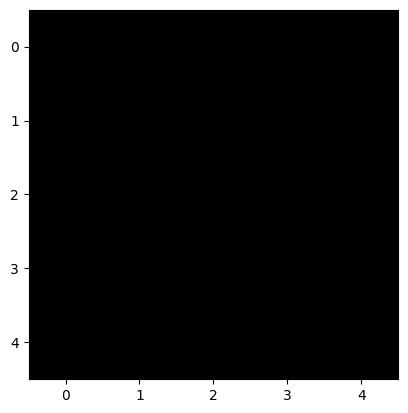

In [ ]:
image2 = np.full((5, 5), 0.5)
draw_image(image2)

In [268]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "my_cmap",
    ["white", "red"]
)

def draw_image_normalized(image):
    plt.imshow(image, cmap=custom_cmap, vmin=0, vmax=1)
    plt.axis('off')
    plt.show()

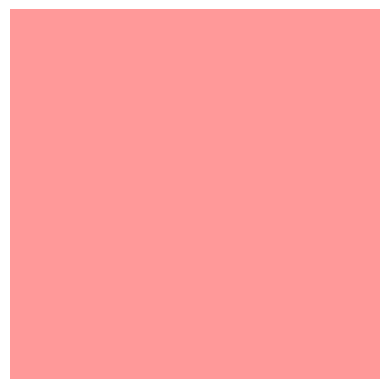

In [269]:
image2 = np.full((5, 5), 0.4)
draw_image_normalized(image2)

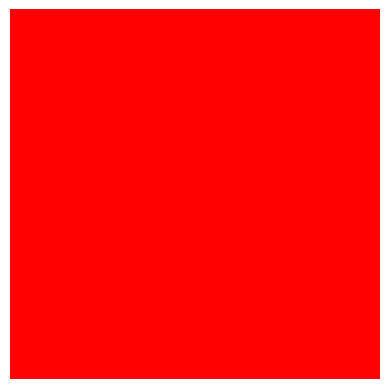

In [270]:
image2 = np.full((5, 5), 0.99)
draw_image_normalized(image2)

In [271]:
array = np.array([[0, 1, 4, 1, 8],
                          [1,0, 1, 0, 1],
                          [0, 1, 0, 1, 0],   
                          [1,0, 1, 0, 1],
                          [0, 1, 0, 1, 0]])
def image_to_vector(matrix):
        matrix = matrix.T
        return np.array([value for row in matrix for value in row])


In [272]:
image_to_vector(array)

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1, 0, 1, 0, 1, 0, 1, 8, 1,
       0, 1, 0])

In [273]:
def vector_to_image(array):
    shape = int(np.sqrt(len(array)))
    matrix = array.reshape((shape, shape))
    return matrix.T

In [274]:
array == vector_to_image(image_to_vector(array))

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

In [275]:
s1 =image_to_vector(np.array([[0,1,0,1,0],
                        [1,0,1,0,1],
                        [0,1,0,1,0],
                        [1,0,1,0,1],
                        [0,1,0,1,0]]) )

s2 = image_to_vector(np.array([[1,0,1,0,1],
                        [0,1,0,1,0],
                        [1,0,1,0,1],
                        [0,1,0,1,0],
                        [1,0,1,0,1]]) )

In [276]:
s1.dot(s2)

np.int64(0)

In [277]:
def element(a,b):
    return a*s2+b*s1

In [1]:
m = 2
n = 5
#implementation du sensing operator
def sensing_operator(n):
    m = np.array([np.zeros(int(n*n)), np.zeros(int(n*n))])
    m[0,0] = 1; m[1,1] = 1
    return m

sensing_operator(5)

NameError: name 'np' is not defined

In [279]:
z = element(0.7,0.4)
y = sensing_operator(5).dot(element(0.7,0.4))
def vector_to_imag2(vector):
    #la taille de l'image est la 5*5 les deux elements de la matrice sont y et les auters sont 0
    image = np.zeros((5,5))
    image[0,0] = vector[0] 
    image[1,0] = vector[1]
    return image
y

array([0.7, 0.4])

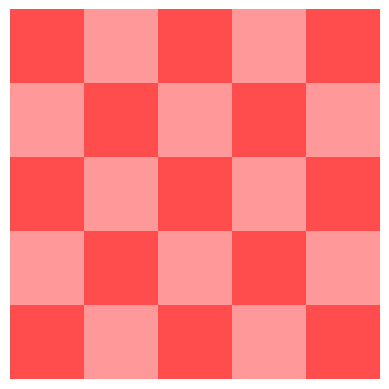

In [280]:
draw_image_normalized(vector_to_image(z))

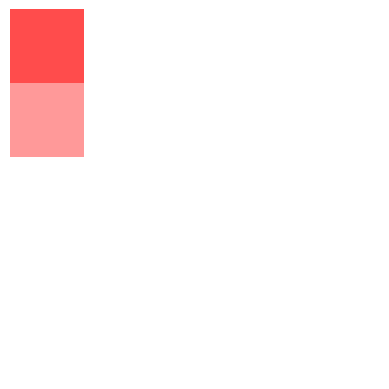

In [281]:
draw_image_normalized(vector_to_imag2(y))

In [282]:
#implementation de la pseudo inverse du sensing operator
def pseudo_inverse(m):
    return np.linalg.pinv(m)

In [283]:
#fonction qui retrouve l'image a partir de y
def decoder1(y):
    M = sensing_operator(5)
    pseudo_inv = pseudo_inverse(M)
    return pseudo_inv.dot(y)

def decoder2(y):
    M = sensing_operator(5)
    V = np.array([s1, s2]).T
    pseudo_inv = pseudo_inverse(M.dot(V))
    return V.dot(pseudo_inv.dot(y))

decoder1(y)
decoder2(y)

array([0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7,
       0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7, 0.4, 0.7])

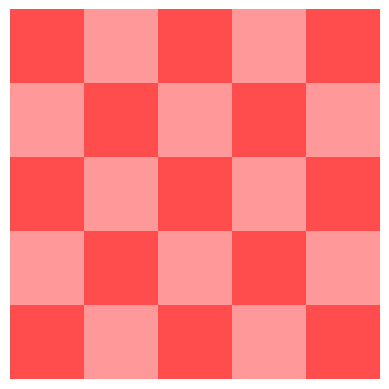

In [284]:
draw_image_normalized(vector_to_image(decoder2(y)))

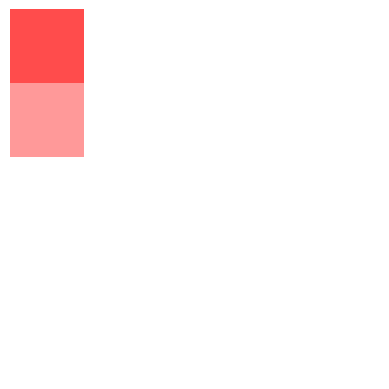

In [ ]:
# draw_image_normalized(vector_to_image(decoder1(y)))